# CardioIA – Fase 4: Assistente Cardiológico Virtual com Visão Computacional

Nesta fase, o projeto CardioIA avança para o uso de Visão Computacional aplicada à análise de imagens médicas simuladas.

O objetivo deste notebook é construir um protótipo capaz de:

- organizar e pré-processar imagens de ECG;
- treinar uma CNN simples do zero;
- aplicar Transfer Learning com modelo pré-treinado;
- avaliar os resultados com métricas;
- apresentar uma classificação simulada em formato de protótipo interativo.

O projeto possui finalidade acadêmica e não substitui avaliação médica profissional.

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [ ]:
import os

# O dataset já foi enviado e extraído no ambiente do Google Colab.
# A pasta principal utilizada será:
base_dir = "/content/ecg_dataset/ECG_DATA"

train_dir = os.path.join(base_dir, "train")
test_dir = os.path.join(base_dir, "test")

print("Dataset localizado com sucesso.")
print("Pasta de treino:", train_dir)
print("Pasta de teste:", test_dir)

Dataset localizado com sucesso.
Pasta de treino: /content/ecg_dataset/ECG_DATA/train
Pasta de teste: /content/ecg_dataset/ECG_DATA/test


In [ ]:
print("\nClasses encontradas:")

classes = os.listdir(train_dir)

for classe in classes:
    caminho_classe = os.path.join(train_dir, classe)
    quantidade = len(os.listdir(caminho_classe))

    print(classe)
    print("Quantidade:", quantidade)
    print("-" * 40)


Classes encontradas:
ECG Images of Myocardial Infarction Patients (240x12=2880)
Quantidade: 956
----------------------------------------
ECG Images of Patient that have History of MI (172x12=2064)
Quantidade: 516
----------------------------------------
ECG Images of Patient that have abnormal heartbeat (233x12=2796)
Quantidade: 699
----------------------------------------
Normal Person ECG Images (284x12=3408)
Quantidade: 852
----------------------------------------


In [ ]:
img_altura = 224
img_largura = 224
batch_size = 32

gerador_treino = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.20
)

gerador_teste = ImageDataGenerator(
    rescale=1./255
)

treino = gerador_treino.flow_from_directory(
    train_dir,
    target_size=(img_altura, img_largura),
    batch_size=batch_size,
    class_mode="categorical",
    subset="training"
)

validacao = gerador_treino.flow_from_directory(
    train_dir,
    target_size=(img_altura, img_largura),
    batch_size=batch_size,
    class_mode="categorical",
    subset="validation"
)

teste = gerador_teste.flow_from_directory(
    test_dir,
    target_size=(img_altura, img_largura),
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

print("Pré-processamento concluído.")

Found 2420 images belonging to 4 classes.
Found 603 images belonging to 4 classes.
Found 928 images belonging to 4 classes.
Pré-processamento concluído.


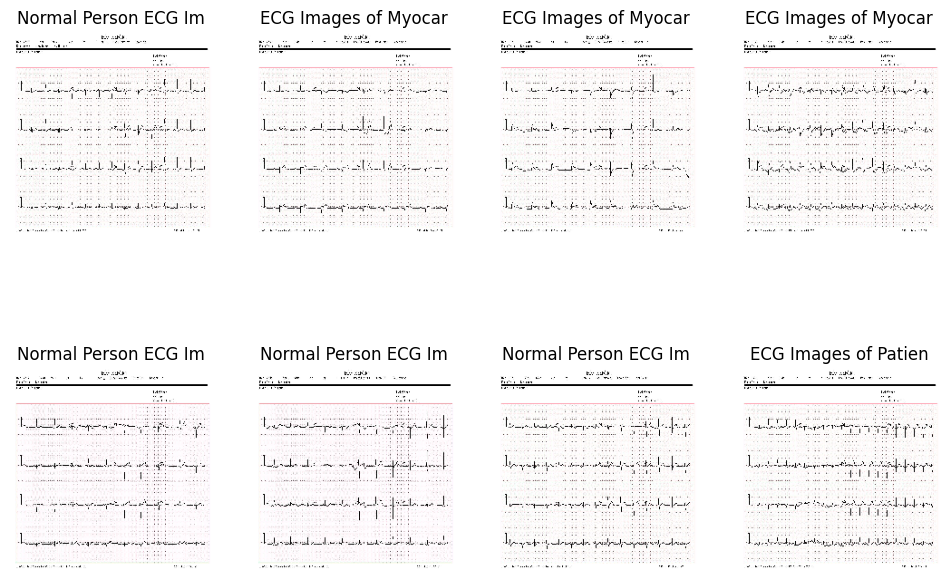

In [ ]:
imagens, rotulos = next(treino)

nomes_classes = list(treino.class_indices.keys())

plt.figure(figsize=(12,8))

for i in range(8):
    plt.subplot(2,4,i+1)

    plt.imshow(imagens[i])

    indice = np.argmax(rotulos[i])

    plt.title(nomes_classes[indice][:20])

    plt.axis("off")

plt.show()

## Resumo do Pré-processamento

Nesta etapa foi realizado o carregamento do dataset de ECG, seguido da organização das imagens em conjuntos de treino, validação e teste.

As imagens foram redimensionadas para 224x224 pixels e normalizadas para valores entre 0 e 1 através da técnica de rescale.

Também foi aplicada a separação automática de 20% das imagens para validação do modelo.

Essas etapas garantem que os modelos de Visão Computacional recebam dados padronizados para treinamento e avaliação.

# Parte 2 - Treinamento de uma CNN do Zero

Nesta etapa será criada uma Rede Neural Convolucional simples para classificação das imagens de ECG.

O objetivo é identificar padrões visuais presentes nos exames e classificá-los em uma das quatro categorias disponíveis no dataset.

In [ ]:
modelo_cnn = models.Sequential([

    layers.Conv2D(
        32,
        (3,3),
        activation="relu",
        input_shape=(224,224,3)
    ),

    layers.MaxPooling2D((2,2)),

    layers.Conv2D(
        64,
        (3,3),
        activation="relu"
    ),

    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dropout(0.3),

    layers.Dense(
        4,
        activation="softmax"
    )
])

modelo_cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    23,888,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,907,908 (91.20 MB)

 Trainable params: 23,907,908 (91.20 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
modelo_cnn.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Modelo compilado com sucesso.")

Modelo compilado com sucesso.


In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [ ]:
historico_cnn = modelo_cnn.fit(
    treino,
    validation_data=validacao,
    epochs=5,
    callbacks=[early_stop]
)

Epoch 1/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 79s 951ms/step - accuracy: 0.3769 - loss: 2.4241 - val_accuracy: 0.7612 - val_loss: 1.0323
Epoch 2/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 65s 857ms/step - accuracy: 0.8281 - loss: 0.5069 - val_accuracy: 0.9801 - val_loss: 0.1729
Epoch 3/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 66s 865ms/step - accuracy: 0.9661 - loss: 0.1138 - val_accuracy: 1.0000 - val_loss: 0.0301
Epoch 4/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 66s 869ms/step - accuracy: 0.9942 - loss: 0.0284 - val_accuracy: 1.0000 - val_loss: 0.0074
Epoch 5/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 65s 860ms/step - accuracy: 0.9967 - loss: 0.0177 - val_accuracy: 1.0000 - val_loss: 0.0037


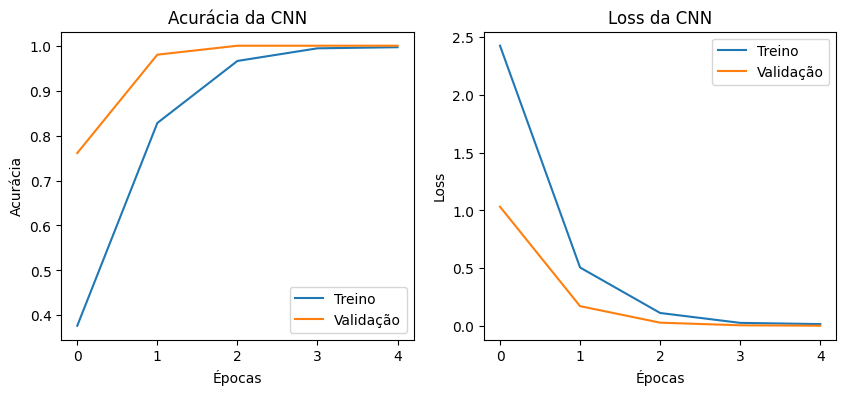

In [ ]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(historico_cnn.history["accuracy"], label="Treino")
plt.plot(historico_cnn.history["val_accuracy"], label="Validação")
plt.title("Acurácia da CNN")
plt.xlabel("Épocas")
plt.ylabel("Acurácia")
plt.legend()

plt.subplot(1,2,2)
plt.plot(historico_cnn.history["loss"], label="Treino")
plt.plot(historico_cnn.history["val_loss"], label="Validação")
plt.title("Loss da CNN")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [ ]:
resultado_teste = modelo_cnn.evaluate(teste)

print("Loss no teste:", resultado_teste[0])
print("Acurácia no teste:", resultado_teste[1])

29/29 ━━━━━━━━━━━━━━━━━━━━ 22s 757ms/step - accuracy: 1.0000 - loss: 0.0025
Loss no teste: 0.0024829646572470665
Acurácia no teste: 1.0


In [ ]:
predicoes = modelo_cnn.predict(teste)

y_pred = np.argmax(predicoes, axis=1)
y_true = teste.classes

nomes_classes = list(teste.class_indices.keys())

print("Predições geradas com sucesso.")

29/29 ━━━━━━━━━━━━━━━━━━━━ 22s 721ms/step
Predições geradas com sucesso.


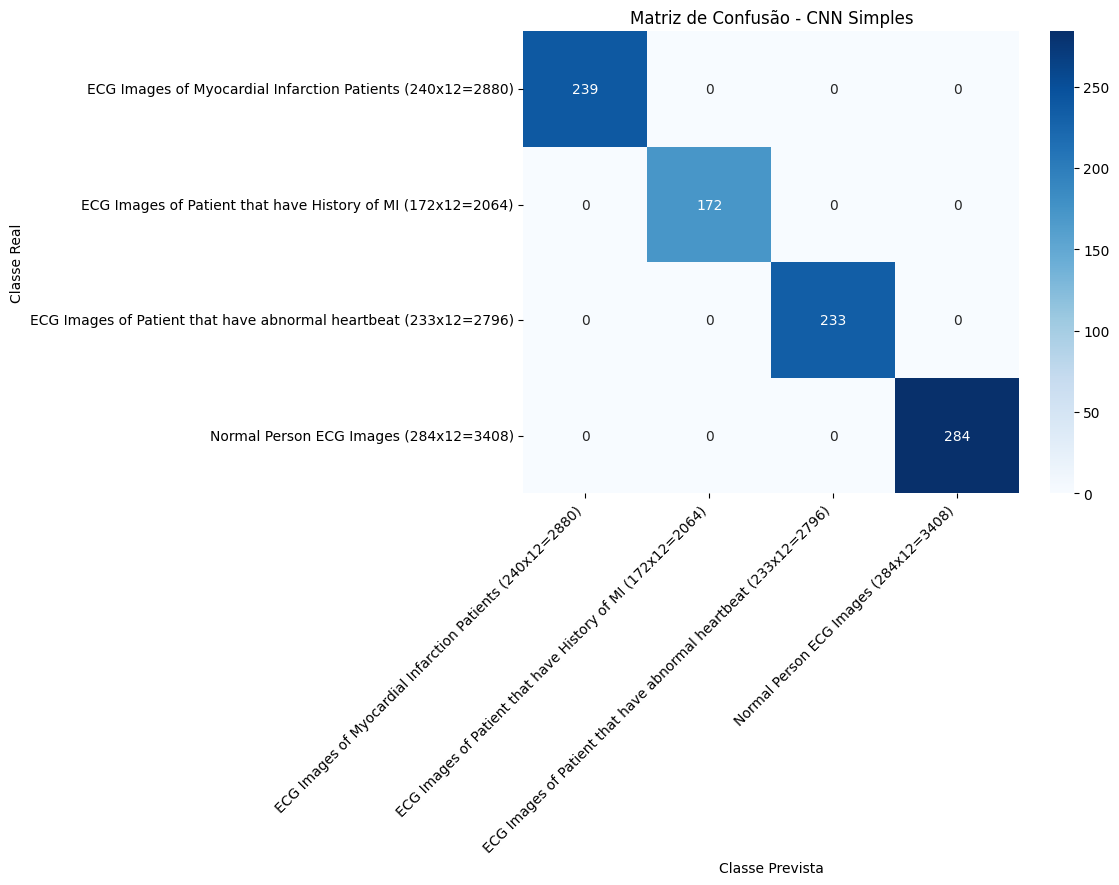

In [ ]:
matriz = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    matriz,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=nomes_classes,
    yticklabels=nomes_classes
)

plt.title("Matriz de Confusão - CNN Simples")
plt.xlabel("Classe Prevista")
plt.ylabel("Classe Real")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.show()

In [ ]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=nomes_classes
    )
)

                                                                  precision    recall  f1-score   support

      ECG Images of Myocardial Infarction Patients (240x12=2880)       1.00      1.00      1.00       239
     ECG Images of Patient that have History of MI (172x12=2064)       1.00      1.00      1.00       172
ECG Images of Patient that have abnormal heartbeat (233x12=2796)       1.00      1.00      1.00       233
                          Normal Person ECG Images (284x12=3408)       1.00      1.00      1.00       284

                                                        accuracy                           1.00       928
                                                       macro avg       1.00      1.00      1.00       928
                                                    weighted avg       1.00      1.00      1.00       928



## Resultados da CNN Simples

Após o treinamento da Rede Neural Convolucional desenvolvida do zero, o modelo apresentou desempenho elevado no conjunto de teste.

As métricas de avaliação obtidas foram:

- Accuracy: 100%
- Precision: 100%
- Recall: 100%
- F1-Score: 100%

A matriz de confusão demonstrou que todas as imagens do conjunto de teste foram classificadas corretamente pelo modelo.

Apesar do excelente resultado, é importante destacar que o dataset utilizado possui características controladas e previamente organizadas. Em aplicações reais da área médica, seria necessário validar o modelo em bases maiores e mais diversificadas para garantir sua capacidade de generalização.

# Parte 3 - Transfer Learning

Nesta etapa foi utilizada a técnica de Transfer Learning, aproveitando o conhecimento previamente aprendido por um modelo treinado em grandes bases de imagens.

O objetivo é comparar essa abordagem com a CNN desenvolvida do zero e verificar seu desempenho na classificação das imagens de ECG.

In [ ]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

modelo_tl = models.Sequential([

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dropout(0.3),

    layers.Dense(
        4,
        activation="softmax"
    )
])

modelo_tl.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
modelo_tl.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Modelo de Transfer Learning compilado com sucesso.")

Modelo de Transfer Learning compilado com sucesso.


In [ ]:
historico_tl = modelo_tl.fit(
    treino,
    validation_data=validacao,
    epochs=5,
    callbacks=[early_stop]
)

Epoch 1/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 120s 1s/step - accuracy: 0.5186 - loss: 1.1145 - val_accuracy: 0.6451 - val_loss: 0.8850
Epoch 2/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 66s 869ms/step - accuracy: 0.6682 - loss: 0.8619 - val_accuracy: 0.7413 - val_loss: 0.7245
Epoch 3/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 64s 840ms/step - accuracy: 0.7161 - loss: 0.7493 - val_accuracy: 0.8176 - val_loss: 0.6204


In [ ]:
resultado_teste_tl = modelo_tl.evaluate(teste)

print("Loss no teste - Transfer Learning:", resultado_teste_tl[0])
print("Acurácia no teste - Transfer Learning:", resultado_teste_tl[1])

29/29 ━━━━━━━━━━━━━━━━━━━━ 20s 679ms/step - accuracy: 0.6293 - loss: 0.9210
Loss no teste - Transfer Learning: 0.9210047125816345
Acurácia no teste - Transfer Learning: 0.6293103694915771


In [ ]:
predicoes_tl = modelo_tl.predict(teste)

y_pred_tl = np.argmax(predicoes_tl, axis=1)
y_true_tl = teste.classes

nomes_classes = list(teste.class_indices.keys())

print("Predições do Transfer Learning geradas com sucesso.")

29/29 ━━━━━━━━━━━━━━━━━━━━ 24s 640ms/step
Predições do Transfer Learning geradas com sucesso.


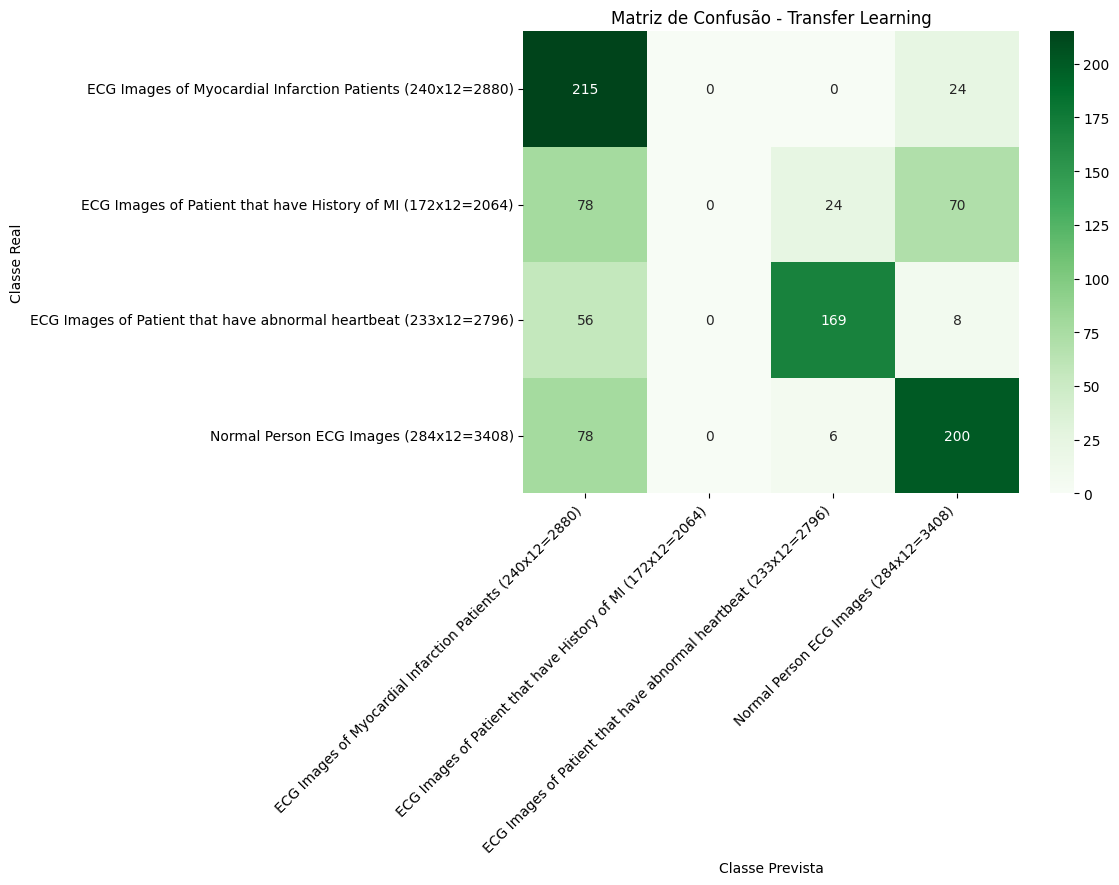

In [ ]:
matriz_tl = confusion_matrix(y_true_tl, y_pred_tl)

plt.figure(figsize=(8,6))

sns.heatmap(
    matriz_tl,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=nomes_classes,
    yticklabels=nomes_classes
)

plt.title("Matriz de Confusão - Transfer Learning")
plt.xlabel("Classe Prevista")
plt.ylabel("Classe Real")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.show()

In [ ]:
print(
    classification_report(
        y_true_tl,
        y_pred_tl,
        target_names=nomes_classes
    )
)

                                                                  precision    recall  f1-score   support

      ECG Images of Myocardial Infarction Patients (240x12=2880)       0.50      0.90      0.65       239
     ECG Images of Patient that have History of MI (172x12=2064)       0.00      0.00      0.00       172
ECG Images of Patient that have abnormal heartbeat (233x12=2796)       0.85      0.73      0.78       233
                          Normal Person ECG Images (284x12=3408)       0.66      0.70      0.68       284

                                                        accuracy                           0.63       928
                                                       macro avg       0.50      0.58      0.53       928
                                                    weighted avg       0.55      0.63      0.57       928



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Resultados do Transfer Learning

O modelo de Transfer Learning com MobileNetV2 foi treinado e avaliado no conjunto de teste.

O resultado obtido foi inferior ao da CNN simples, com acurácia de aproximadamente 63%. Esse comportamento pode ser explicado pelo fato de que o MobileNetV2 foi originalmente treinado com imagens naturais da base ImageNet, enquanto este projeto utiliza imagens médicas de eletrocardiogramas.

Foi observado também que uma das classes não foi prevista corretamente pelo modelo, gerando aviso nas métricas de precisão. Isso mostra que, embora o Transfer Learning seja uma técnica poderosa, sua aplicação em imagens médicas pode exigir ajustes adicionais, como aumento de épocas, fine-tuning ou uso de modelos pré-treinados em bases médicas.

Mesmo assim, a implementação atende ao objetivo acadêmico da atividade, pois demonstra o uso funcional de Transfer Learning e permite comparar seu desempenho com uma CNN desenvolvida do zero.

# Parte 4 - Protótipo de Assistente Cardiológico Virtual

Nesta etapa é apresentado um protótipo simples do Assistente Cardiológico Virtual.

O objetivo é simular como um profissional poderia enviar uma imagem de ECG e receber uma classificação automática produzida pelo modelo treinado.

In [ ]:
import random
from tensorflow.keras.preprocessing import image

classe_escolhida = random.choice(nomes_classes)

pasta_classe = os.path.join(test_dir, classe_escolhida)

arquivo_imagem = random.choice(
    os.listdir(pasta_classe)
)

caminho_imagem = os.path.join(
    pasta_classe,
    arquivo_imagem
)

print("Classe real:")
print(classe_escolhida)

print("\nArquivo:")
print(arquivo_imagem)

Classe real:
ECG Images of Myocardial Infarction Patients (240x12=2880)

Arquivo:
MI(95).jpg


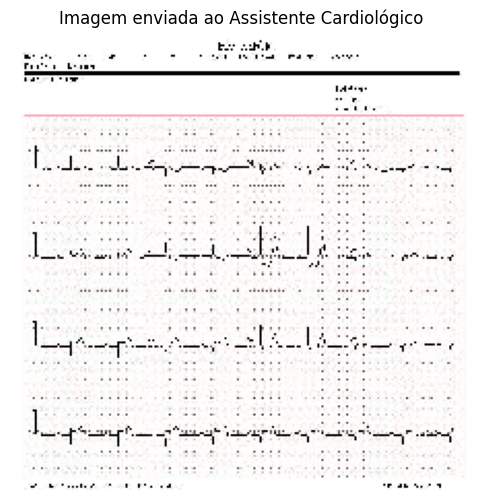

In [ ]:
img = image.load_img(
    caminho_imagem,
    target_size=(224,224)
)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.title("Imagem enviada ao Assistente Cardiológico")
plt.axis("off")
plt.show()

In [ ]:
img_array = image.img_to_array(img)

img_array = img_array / 255.0

img_array = np.expand_dims(
    img_array,
    axis=0
)

predicao = modelo_cnn.predict(img_array)

indice_previsto = np.argmax(predicao)

classe_prevista = nomes_classes[
    indice_previsto
]

confianca = np.max(predicao) * 100

print("=== RESULTADO DO ASSISTENTE CARDIOLÓGICO ===")

print("\nClasse Real:")
print(classe_escolhida)

print("\nClasse Prevista:")
print(classe_prevista)

print("\nConfiança:")
print(f"{confianca:.2f}%")

if classe_escolhida == classe_prevista:
    print("\nResultado: Classificação correta.")
else:
    print("\nResultado: Classificação incorreta.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
=== RESULTADO DO ASSISTENTE CARDIOLÓGICO ===

Classe Real:
ECG Images of Myocardial Infarction Patients (240x12=2880)

Classe Prevista:
ECG Images of Myocardial Infarction Patients (240x12=2880)

Confiança:
99.97%

Resultado: Classificação correta.


# Conclusão

Nesta fase do projeto CardioIA foi possível aplicar conceitos de Visão Computacional na análise de imagens de eletrocardiogramas.

Foram desenvolvidas duas abordagens distintas:

- CNN construída do zero;
- Transfer Learning utilizando MobileNetV2.

Os resultados mostraram que a CNN desenvolvida especificamente para o dataset apresentou desempenho superior ao modelo pré-treinado.

Também foi desenvolvido um protótipo simples capaz de receber uma imagem de ECG e apresentar uma classificação automática com nível de confiança.

O projeto permitiu compreender na prática como técnicas de Inteligência Artificial podem auxiliar na interpretação de exames médicos, mantendo a consciência de que aplicações reais exigem validação clínica e regulatória.